# Clasificación de Jutsus en Tiempo Real
Este notebook carga un modelo entrenado y clasifica frames de la webcam en tiempo real.

Interpreta secuencias de sellos y hace un match con una lista de secuencias predefinidas.

Cada secuencia tiene un nombre asignado, al realizar la secuencia correspondiente se muestra
su nombre.

In [36]:
# Importar librerías necesarias
import cv2
import numpy as np
from tensorflow import keras
from IPython.display import clear_output
import matplotlib.pyplot as plt


In [37]:
# Cargar el modelo entrenado
model = keras.models.load_model('91porciento.keras')
print("Modelo cargado exitosamente")
print(f"Input shape del modelo: {model.input_shape}")

Modelo cargado exitosamente
Input shape del modelo: (None, 300, 300, 3)


In [38]:
# Definir las clases (ajustar según tu modelo)
# Asegúrate de que estas clases coincidan con las que usaste durante el entrenamiento
used_classes = ['bird', 'monkey', 'boar', 'tiger', 'rat', 'ram', 'dog', 'horse', 'hare', 'ox', 'dragon', 'snake']

# Configuración
IMAGE_SIZE = 300  # Ajustar según el tamaño de entrada de tu modelo
FRAMES_THRESHOLD = 10  # Número de frames consecutivos para confirmar una clasificación
CONFIDENCE_THRESHOLD = 0.6  # Umbral de confianza mínimo

# Cargar la lista de jutsus desde el json
def load_jutsus():
    import json
    with open('jutsus/jutsus.json', 'r') as file:
        jutsus = json.load(file)
    return jutsus

# El formato de los jutsus es un diccionario de secuencias(en formato string)
# a nombres de jutsus
# Ejemplo: {"['bird', 'monkey']": "Jutsu1", "['boar', 'tiger']": "Jutsu2", ...}
jutsus = load_jutsus()
predicted_jutsu = None


In [39]:
def preprocess_frame(frame):
    """
    Preprocesa el frame para que sea compatible con el modelo
    """
    # Redimensionar
    frame_resized = cv2.resize(frame, (IMAGE_SIZE, IMAGE_SIZE))
    
    # Agregar dimensión del batch
    frame_batch = np.expand_dims(frame_resized, axis=0)

    return frame_batch

def classify_frame(frame, model):
    """
    Clasifica un frame usando el modelo
    """
    processed_frame = preprocess_frame(frame)
    predictions = model.predict(processed_frame, verbose=0)
    
    class_idx = np.argmax(predictions[0])
    confidence = predictions[0][class_idx]
    
    if confidence > CONFIDENCE_THRESHOLD:
        return used_classes[class_idx], confidence
    else:
        return None, confidence

In [40]:
def update_display(frame, current_prediction, confidence, frame_count, 
                   consecutive_count, sequence):
    """
    Actualiza la visualización con información actual
    """
    clear_output(wait=True)
    
    # Mostrar el frame
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    
    # Subplot para el frame
    plt.subplot(2, 1, 1)
    plt.imshow(frame_rgb)
    plt.title(f'Frame #{frame_count} - Predicción: {current_prediction} (Confianza: {confidence:.2f})')
    plt.axis('off')
    
    # Información de estado
    plt.subplot(2, 1, 2)
    global predicted_jutsu
    if predicted_jutsu:
        plt.title(f'Jutsu predecido: {predicted_jutsu}', fontsize=16)
    plt.text(0.1, 0.8, f'Frames consecutivos: {consecutive_count}/{FRAMES_THRESHOLD}', 
             fontsize=14, transform=plt.gca().transAxes)
    
    plt.text(0.1, 0.6, f'Secuencia actual: {" -> ".join(sequence) if sequence else "Vacía"}', 
             fontsize=14, transform=plt.gca().transAxes)
    
    plt.text(0.1, 0.4, f'Total de sellos en secuencia: {len(sequence)}', 
             fontsize=14, transform=plt.gca().transAxes)

    #plt.text(0.1, 0.3, f'Jutsu predecido: {predicted_jutsu if predicted_jutsu else "Ninguno"}', 
    #         fontsize=14, transform=plt.gca().transAxes)
    
    plt.text(0.1, 0.2, 'Presiona \'q\' en la ventana de OpenCV para salir', 
             fontsize=12, transform=plt.gca().transAxes, style='italic')
    plt.text(0.1, 0.1, 'Presiona \'c\' en la ventana de OpenCV para limpiar la secuencia', 
             fontsize=12, transform=plt.gca().transAxes, style='italic')

    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [41]:
# Función principal de clasificación en tiempo real
def real_time_classification():
    # Inicializar webcam
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("Error: No se pudo abrir la cámara")
        return
    
    # Variables de estado
    sequence = []  # Secuencia de clasificaciones confirmadas
    current_prediction = None
    consecutive_count = 0
    frame_count = 0
    last_confirmed_class = None
    global predicted_jutsu
    predicted_jutsu = None
    
    print("Iniciando clasificación en tiempo real...")
    print("Presiona 'q' en la ventana de OpenCV para salir")
    print("Presiona 'c' en la ventana de OpenCV para limpiar la secuencia")

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print("Error: No se pudo leer el frame")
                break
            
            frame_count += 1
            
            # Clasificar el frame actual
            predicted_class, confidence = classify_frame(frame, model)
            
            # Actualizar contador de frames consecutivos
            if predicted_class == current_prediction and predicted_class is not None:
                consecutive_count += 1
            else:
                current_prediction = predicted_class
                consecutive_count = 1 if predicted_class is not None else 0
            
            # Verificar si se alcanzó el umbral para confirmar la clasificación
            if (consecutive_count >= FRAMES_THRESHOLD and 
                current_prediction is not None and 
                current_prediction != last_confirmed_class):
                
                sequence.append(current_prediction)
                last_confirmed_class = current_prediction
                consecutive_count = 0  # Resetear contador
                
                # Verificar si esta secuencia de sellos corresponde a un jutsu
                # si es asi, mostrar el nombre del jutsu correspondiente
                str_sequence = str(sequence)
                
                if str_sequence in jutsus:
                    predicted_jutsu = jutsus[str_sequence]
                else:
                    predicted_jutsu = None

            
            # Mostrar frame con información (cada 5 frames para mejor rendimiento)
            if frame_count % 5 == 0:
                display_prediction = current_prediction if current_prediction else "Ninguna"
                update_display(frame, display_prediction, confidence, 
                             frame_count, consecutive_count, sequence)
            
            # Mostrar frame en ventana de OpenCV (opcional)
            cv2.putText(frame, f'Pred: {current_prediction or "None"}', 
                       (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            cv2.putText(frame, f'Frames: {consecutive_count}/{FRAMES_THRESHOLD}', 
                       (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            cv2.putText(frame, f'Secuencia: {len(sequence)}', 
                       (10, 110), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            if predicted_jutsu:
                cv2.putText(frame, f'Jutsu: {predicted_jutsu}', 
                           (10, 150), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            
            cv2.imshow('Clasificacion en Tiempo Real', frame)
            
            # Salir si se presiona 'q'
            key = cv2.waitKey(1)
            if key & 0xFF == ord('q'):
                break

            # Limpiar secuencia si se presiona 'c'
            if key & 0xFF == ord('c'):
                # Limpiar la secuencia
                sequence = []
                current_prediction = None
                consecutive_count = 0
                last_confirmed_class = None
                predicted_jutsu = None
                
    except KeyboardInterrupt:
        print("\nInterrumpido por el usuario")
    
    finally:
        # Limpiar recursos
        cap.release()
        cv2.destroyAllWindows()
        
        # Mostrar secuencia final
        print("\n=== SECUENCIA FINAL ===")
        if sequence:
            print(f"Secuencia de sellos: {' -> '.join(sequence)}")
            print(f"Total de sellos detectados: {len(sequence)}")
        else:
            print("No se detectaron sellos confirmados")
        
        return sequence

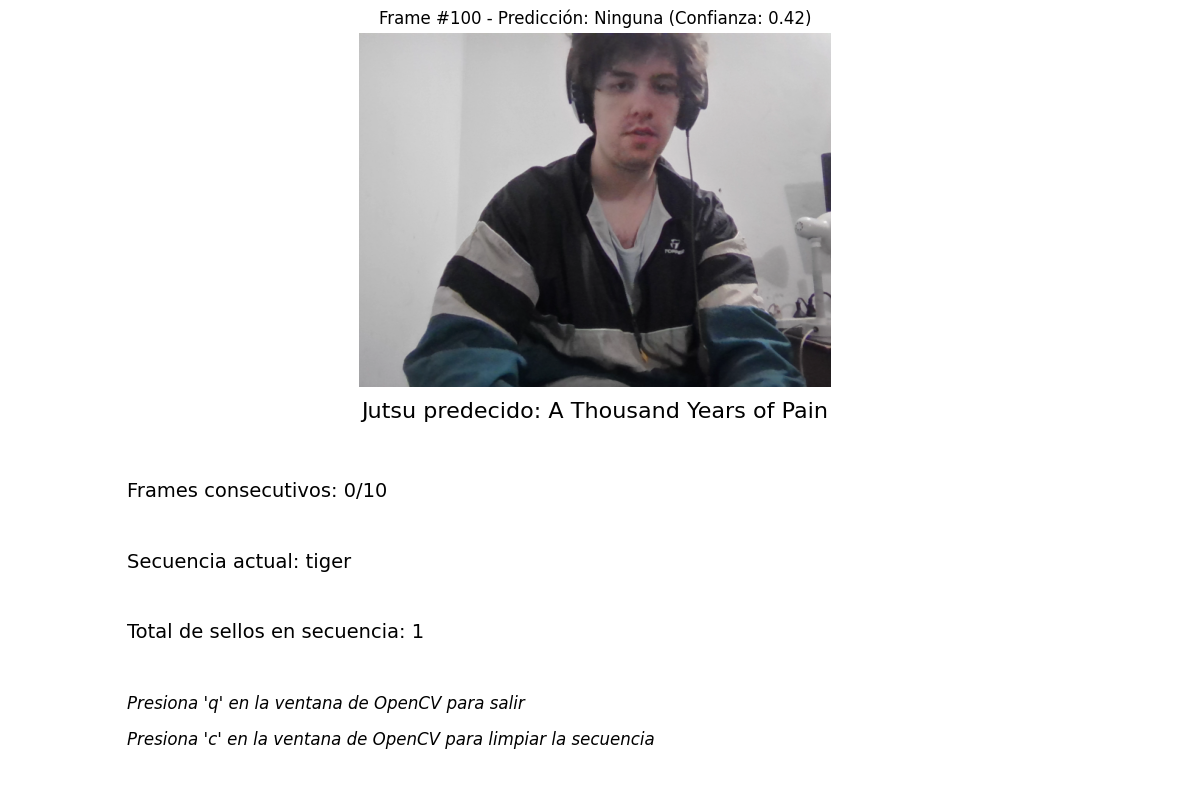


=== SECUENCIA FINAL ===
Secuencia de sellos: tiger
Total de sellos detectados: 1


In [42]:
# Ejecutar la clasificación en tiempo real
detected_sequence = real_time_classification()